In [ ]:
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [18]:
df=yf.download("AAPL", start="2024-01-01", end="2026-03-20")

[*********************100%***********************]  1 of 1 completed


In [19]:
df.columns=df.columns.get_level_values(0)

In [20]:
df["target"] = df["Close"].shift(-1)
df.dropna(inplace=True)

In [21]:
df.head()

Price,Close,High,Low,Open,Volume,target
Date,,,,,,
2024-01-02,183.731323,186.502538,181.999316,185.225793,82488700,182.355606
2024-01-03,182.355606,183.968852,181.544030,182.325916,58414500,180.039658
2024-01-04,180.039658,181.207518,179.020249,180.277180,71983600,179.317154
2024-01-05,179.317154,180.880911,178.317544,180.118838,62379700,183.652145
2024-01-08,183.652145,183.691743,179.633891,180.217821,59144500,183.236435


In [22]:
print({len(df)})

{554}


In [24]:
X=df[["Open", "High", "Low", "Volume"]]
Y=df["target"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [25]:
Model = LinearRegression()
Model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
predictions = Model.predict(X_test)

In [ ]:
print(predictions[:10])

print(f"Number of predictions: {len(predictions)}")

[170.51847696 173.90900422 223.55658796 269.13003762 226.494224
 255.66168343 226.36773732 180.89922443 223.61923869 228.24239305]
Number of predictions: 111


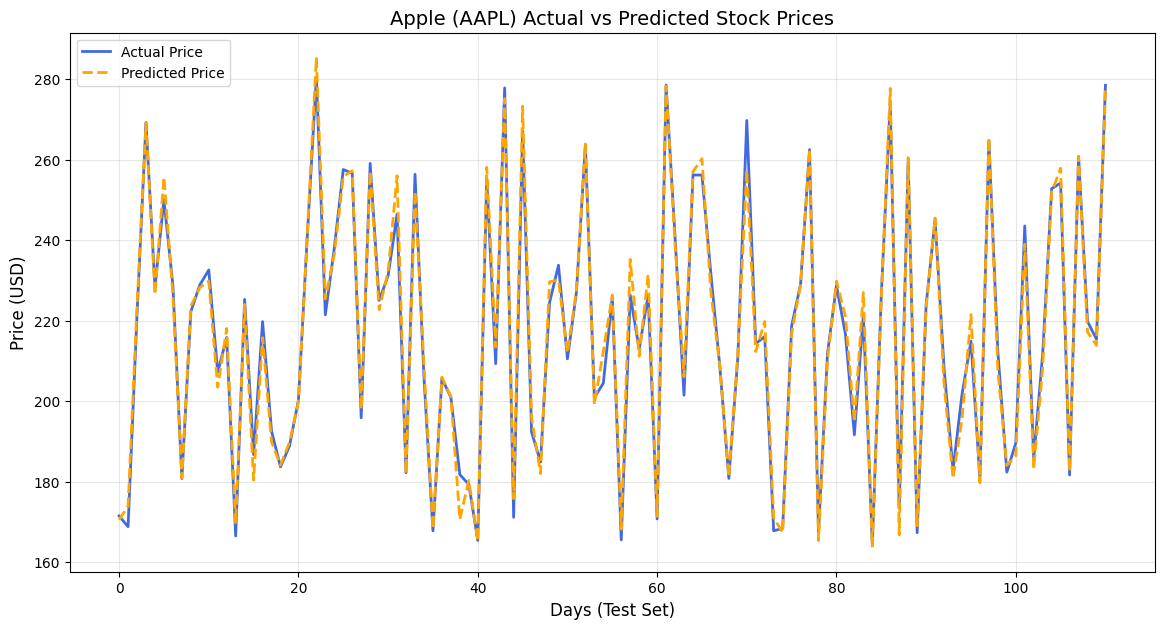

In [31]:


plt.figure(figsize=(14, 7))

plt.plot(Y_test.values, label='Actual Price', color='royalblue', linewidth=2)

plt.plot(predictions, label='Predicted Price', color='orange', linestyle='--', linewidth=2)


plt.title('Apple (AAPL) Actual vs Predicted Stock Prices', fontsize=14)
plt.xlabel('Days (Test Set)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()